<a href="https://colab.research.google.com/github/clusterZX98/E-Commerce-Sales-Analytics/blob/main/E_Commerce_Sales_Analytics_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import the liabraray

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")


# Load the dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/data set/Global_Superstore2.csv", encoding='latin1')
print(df.head(8))

   Row ID         Order ID  Order Date   Ship Date       Ship Mode  \
0   32298   CA-2012-124891  31-07-2012  31-07-2012        Same Day   
1   26341    IN-2013-77878  05-02-2013  07-02-2013    Second Class   
2   25330    IN-2013-71249  17-10-2013  18-10-2013     First Class   
3   13524  ES-2013-1579342  28-01-2013  30-01-2013     First Class   
4   47221     SG-2013-4320  05-11-2013  06-11-2013        Same Day   
5   22732    IN-2013-42360  28-06-2013  01-07-2013    Second Class   
6   30570    IN-2011-81826  07-11-2011  09-11-2011     First Class   
7   31192    IN-2012-86369  14-04-2012  18-04-2012  Standard Class   

  Customer ID     Customer Name      Segment           City            State  \
0    RH-19495       Rick Hansen     Consumer  New York City         New York   
1    JR-16210     Justin Ritter    Corporate     Wollongong  New South Wales   
2    CR-12730      Craig Reiter     Consumer       Brisbane       Queensland   
3    KM-16375  Katherine Murray  Home Office     

# Data exploration

In [ ]:
df.shape

(51290, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [ ]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
count,51290.00000,51290,51290,51290,51290,51290,51290,51290,51290,51290,...,51290,51290,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290
unique,NaN,25035,1430,1464,4,1590,795,3,3636,1094,...,10292,3,17,3788,NaN,NaN,NaN,NaN,NaN,4
top,NaN,CA-2014-100111,18-06-2014,22-11-2014,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,...,OFF-AR-10003651,Office Supplies,Binders,Staples,NaN,NaN,NaN,NaN,NaN,Medium
freq,NaN,14,135,130,30775,97,108,26518,915,2001,...,35,31273,6152,227,NaN,NaN,NaN,NaN,NaN,29433
mean,25645.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,246.490581,3.476545,0.142908,28.610982,26.375915,NaN
std,14806.29199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,487.565361,2.278766,0.212280,174.340972,57.296804,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000,0.000000,NaN
25%,12823.25000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,30.758625,2.000000,0.000000,0.000000,2.610000,NaN
50%,25645.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,85.053000,3.000000,0.000000,9.240000,7.790000,NaN
75%,38467.75000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,251.053200,5.000000,0.200000,36.810000,24.450000,NaN


# Data cleaning

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
City,0
State,0


. postal code contains approximately 80% mising values data and it is not required for the current business analysis . so,drop that coulmn helps to enhance the data.

# Data cleaning

In [ ]:
# drop postal column
df.drop(columns=['Postal Code'], inplace=True)

In [ ]:
# drop duplictes
df.drop_duplicates(inplace=True)

In [ ]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    dayfirst=True
)

In [ ]:
df[['Order Date', 'Ship Date']].dtypes


,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


# Feature engineering
creating new columns


In [ ]:
df['Order Month'] = df['Order Date'].dt.month_name()
df['Order Year'] = df['Order Date'].dt.year
df['Profit Margin'] = ( df['Profit'] / df['Sales']) * 100

# Business analysis

In [ ]:
# Total sales
df['Sales'].sum()

np.float64(12642501.909880001)

In [ ]:
# Total profit
df['Profit'].sum()

np.float64(1467457.29128)

In [ ]:
# Total order
df['Order ID'].nunique()

25035

In [ ]:
# AOV(Average Order Value)
df['Sales'].sum() / df['Order ID'].nunique()

np.float64(504.9930860746955)

# Customer Analysis


In [ ]:
# Top 10 Customers
top_customer = df['Customer Name'].value_counts().head(10)
top_customer

,count
Customer Name,
Muhammed Yedwab,108
Steven Ward,106
Gary Hwang,102
Patrick O'Brill,102
Bill Eplett,102
Harry Greene,101
Eric Murdock,100
Art Ferguson,98
Brosina Hoffman,97


In [ ]:
# Top 10 Customers by sales
top_customers = df.groupby(
    'Customer Name'
)['Sales'].sum().sort_values(
    ascending=False
).head(10)

top_customers

,Sales
Customer Name,
Tom Ashbrook,40488.07080
Tamara Chand,37457.33300
Greg Tran,35550.95428
Christopher Conant,35187.07640
Sean Miller,35170.93296
Bart Watters,32310.44650
Natalie Fritzler,31781.25850
Fred Hopkins,30400.67452
Jane Waco,30288.45030


In [ ]:
# Most Valuable Customers = it's decided on the basis of profit because most sales != most valuable
df.groupby(
    'Customer Name'
)['Profit'].sum().sort_values(
    ascending=False
).head(10)

,Profit
Customer Name,
Tamara Chand,8672.89890
Raymond Buch,8453.04950
Sanjit Chand,8205.37990
Hunter Lopez,7816.56778
Bill Eplett,7410.00530
Harry Marie,6958.28640
Susan Pistek,6484.40726
Mike Gockenbach,6458.67620
Adrian Barton,6417.28450


In [ ]:
#Customer Segment Analysis
i = df['Segment'].value_counts().head(10)
i

,count
Segment,
Consumer,26518
Corporate,15429
Home Office,9343


In [ ]:
df.groupby('Segment')[
    ['Sales', 'Profit']
].sum()

,Sales,Profit
Segment,,
Consumer,6.507949e+06,749239.78206
Corporate,3.824698e+06,441208.32866
Home Office,2.309855e+06,277009.18056


. segment analysis tells that the consumer segment is most profitable

# Product Analysis


In [ ]:
top_selling_products = df.groupby('Product Name')[
    'Sales'
].sum().sort_values(
    ascending=False
).head(10)

In [ ]:
#Most Profitable Products
df.groupby('Product Name')['Profit'].sum().sort_values(
    ascending=False).head(10)

,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
"Cisco Smart Phone, Full Size",17238.5206
"Motorola Smart Phone, Full Size",17027.1130
"Hoover Stove, Red",11807.9690
"Sauder Classic Bookcase, Traditional",10672.0730
"Harbour Creations Executive Leather Armchair, Adjustable",10427.3260
"Nokia Smart Phone, Full Size",9938.1955
"Cisco Smart Phone, with Caller ID",9786.6408
"Nokia Smart Phone, with Caller ID",9465.3257


In [ ]:
#Worst Performing Products
df.groupby('Product Name')[
    'Profit'
].sum().sort_values(
    ascending=False
).tail(10)

,Profit
Product Name,
"Lesro Training Table, Rectangular",-2581.2834
"Bevis Wood Table, with Bottom Storage",-2782.5880
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.1156
"Rogers Lockers, Blue",-2893.4908
"Bevis Computer Table, Fully Assembled",-3509.5638
"Bevis Round Table, Adjustable Height",-3649.8940
Cubify CubeX 3D Printer Triple Head Print,-3839.9904
"Motorola Smart Phone, Cordless",-4447.0380
Lexmark MX611dhe Monochrome Laser Printer,-4589.9730


# Regional Analysis


In [ ]:
#Best Region
df.groupby('Region')[
    'Sales'
].sum().sort_values(ascending=False)

,Sales
Region,
Central,2.822303e+06
South,1.600907e+06
North,1.248166e+06
Oceania,1.100185e+06
Southeast Asia,8.844232e+05
North Asia,8.483098e+05
EMEA,8.061613e+05
Africa,7.837732e+05
Central Asia,7.528266e+05


In [ ]:
# Worst Region
df.groupby('Region')[
    'Sales'
].sum().sort_values(ascending=False).tail(5)

,Sales
Region,
Central Asia,752826.56700
West,725457.82450
East,678781.24000
Caribbean,324280.86104
Canada,66928.17000


In [ ]:
# Highest Profit State
df.groupby('State')['Profit'].sum().sort_values(
    ascending=False
).head()

,Profit
State,
England,99907.7310
California,76381.3871
New York,74038.5486
Ile-de-France,44055.9240
New South Wales,43695.9840


In [ ]:
# Lowest Profit State
df.groupby('State')['Profit'].sum().sort_values().head()

,Profit
State,
Istanbul,-29033.7000
Lagos,-25922.5110
Texas,-25729.3563
Ohio,-16971.3766
Izmir,-15729.8040


# Time Series Analysis


In [ ]:
# Monthly Sales Trend
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M'))['Sales'].sum()

In [ ]:
# Yearly Growth
yearly_sales = df.groupby(
    'Order Year'
)['Sales'].sum()

yearly_sales.pct_change() * 100

,Sales
Order Year,
2011,NaN
2012,18.499530
2013,27.201659
2014,26.253259


.pct_changes() = This pandas function looks at every year's total and divides it by the previous year's total, then subtracts 1 to get the fractional change.
why 2011 is nan(not a number)?
beacuse  there is no prior year to compare it against.
# insight:
. from 2012 -2013 sales increased by 9% but due to some reason sales falls 1% from 2013 - 2014

In [ ]:
# Seasonal Trends
df.groupby('Order Month')['Sales'].sum()

,Sales
Order Month,
April,6.985612e+05
August,1.293833e+06
December,1.580781e+06
February,5.437394e+05
January,6.751337e+05
July,7.493818e+05
June,1.269717e+06
March,7.705009e+05
May,9.040123e+05


. according to the seasonal trend april,february,january,july,march,may performs the best months

# Visualization Section

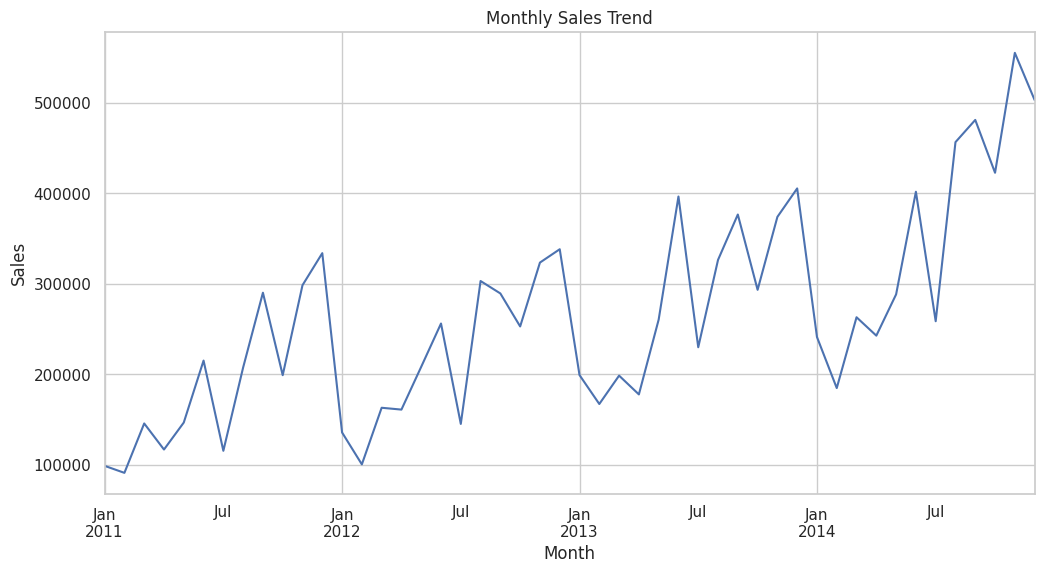

In [ ]:
# 1. Sales Trend
monthly_sales.plot(figsize=(12,6))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()



1.  this chart shows the upward trends.
2.  you can track that there is some downfalls in the january months in every years.





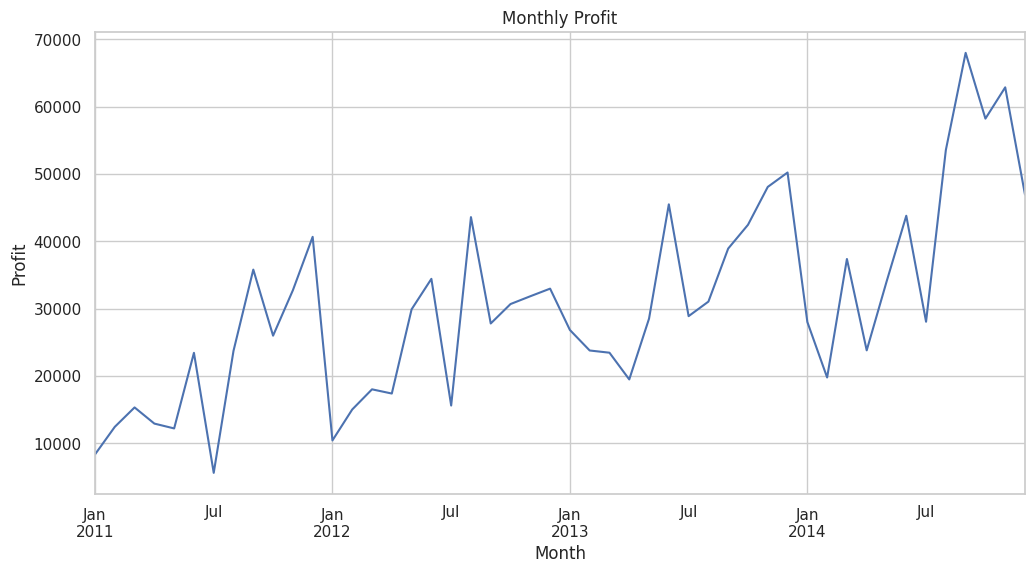

In [ ]:
# 2. Profit Trend
monthly_profit = df.groupby(
    df['Order Date'].dt.to_period('M'))['Profit'].sum()
monthly_profit.plot(figsize=(12,6))
plt.title('Monthly Profit')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.show()


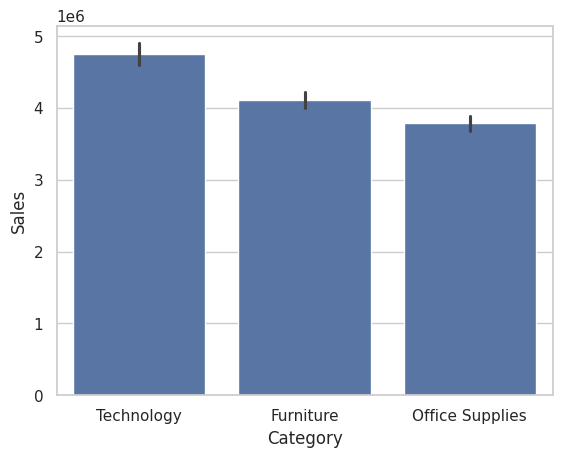

In [ ]:
# 3. Sales by Category
sns.barplot(
    x='Category',
    y='Sales',
    data=df,
    estimator=sum
)

plt.show()

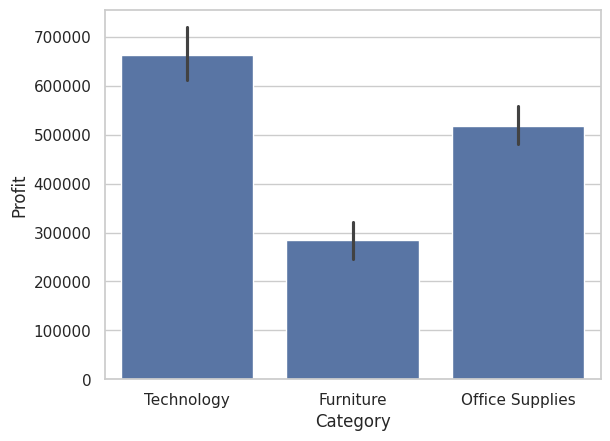

In [ ]:
# 4. Profit by Category
sns.barplot(
    x='Category',
    y='Profit',
    data=df,
    estimator=sum
)

plt.show()

The Technology category generated the highest sales and profits, suggesting the company should prioritize technology inventory and marketing campaigns.

<Axes: ylabel='Customer Name'>

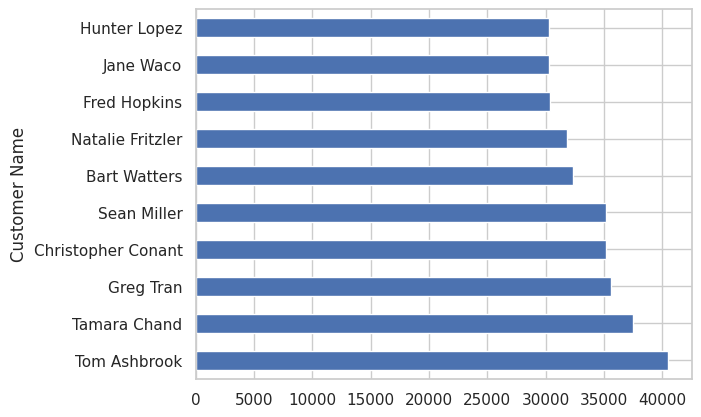

In [ ]:
# 5. Top Customers
top_customers.plot(kind='barh')

<Axes: ylabel='Product Name'>

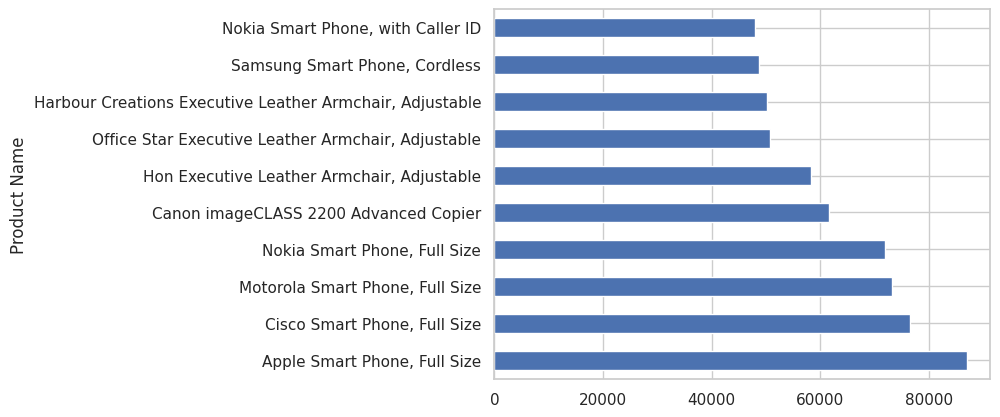

In [ ]:
# 6. Top Products
top_selling_products.plot(kind='barh')

. company should increase the stock & inventory in a store of a particular product that comes in most demanded items

<Axes: ylabel='Sales'>

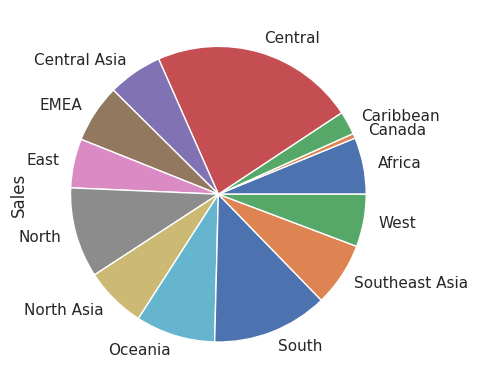

In [ ]:
# 7. Region Wise Sales
df.groupby('Region')['Sales'].sum().plot(kind='pie')

# Insight

*   central region generates the most of sells .
*   company should focus on the region which creates less sells .
*   if the region had less no. of stores. probably that is the reason of less sales.



<Axes: >

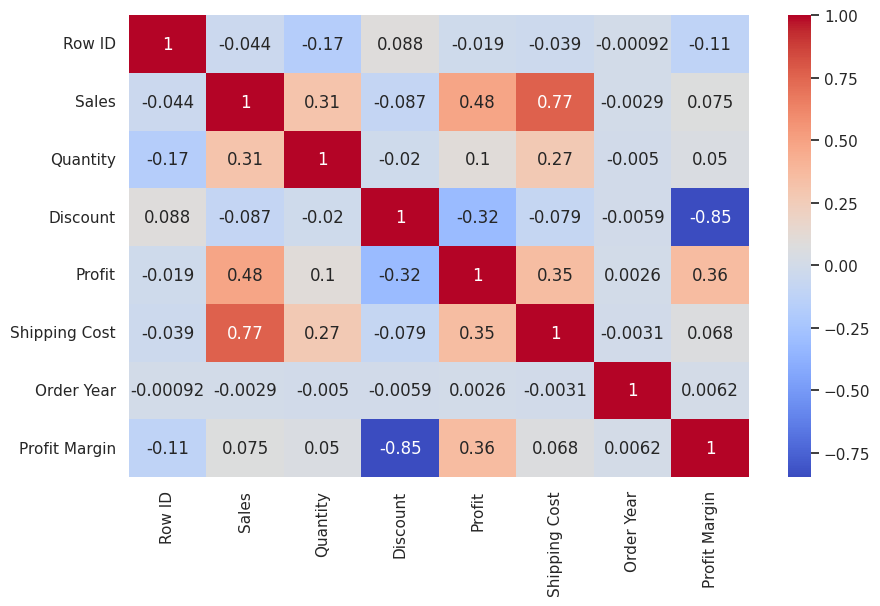

In [ ]:
# 8. Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

# insight

*   Shipping cost has a strong positive correlation with sales (0.77), indicating that larger orders incur higher logistics expenses.

*   Discount has a strong negative correlation with profit margin (-0.85), suggesting that aggressive discounting significantly reduces profitability.

*   Sales and profit show a moderate positive relationship (0.48), indicating that increasing revenue does not always guarantee proportional profit growth.

*   Quantity sold has a moderate positive correlation with sales (0.31), highlighting opportunities for bundle pricing and volume-based promotions.



<Axes: xlabel='Sales', ylabel='Count'>

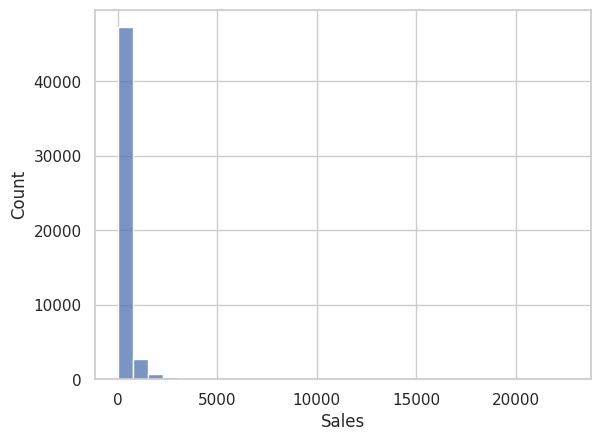

In [ ]:
# 9. Histogram
sns.histplot(df['Sales'], bins=30)

#  Insight


*   Most orders have low sales values.,Very few orders have extremely high sales.
*   right-skewed distribution.
*   Recommendation =Increase average order value through upselling,Protect relationships with high-value customers.



<Axes: xlabel='Profit'>

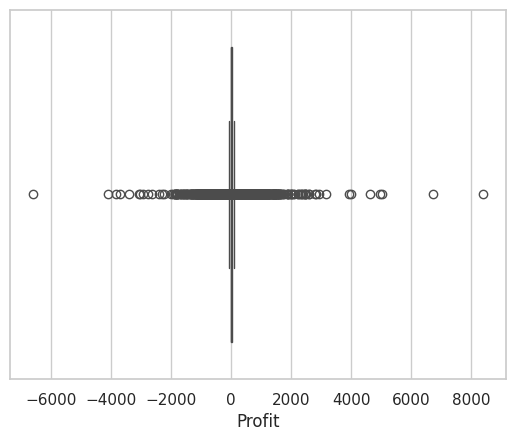

In [ ]:
# 10. Boxplot
sns.boxplot(x=df['Profit'])

# Insight


*   Most profits are close to zero.
*   Many outliers exist on both sides.
*   Some orders create very large losses.
*   recommendation = Investigate highly negative profit orders,Check if discounts, shipping costs, or specific products cause losses.



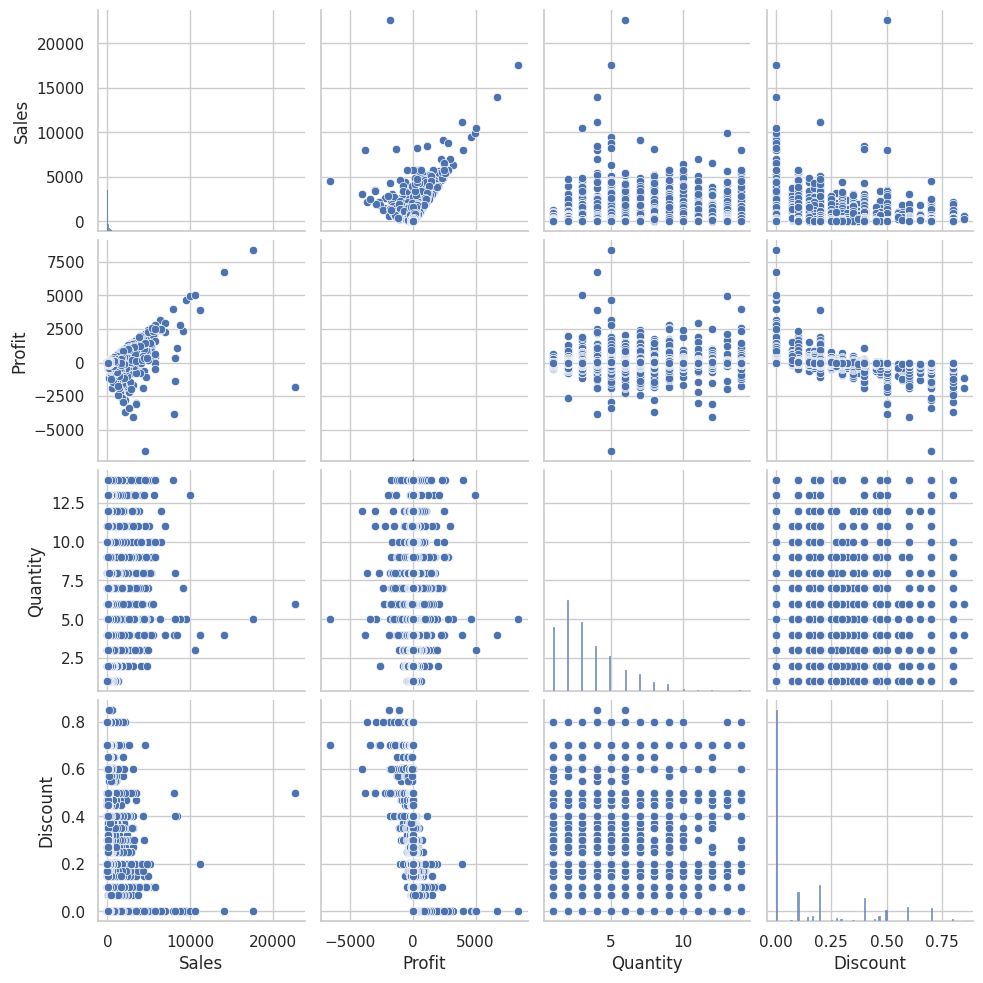

In [ ]:
# 11. Pairplot
sns.pairplot(
    df[['Sales', 'Profit', 'Quantity', 'Discount']]
)

In [ ]:
# 12. Correlation Matrix
# Already done using heatmap.

<Axes: xlabel='Order Date'>

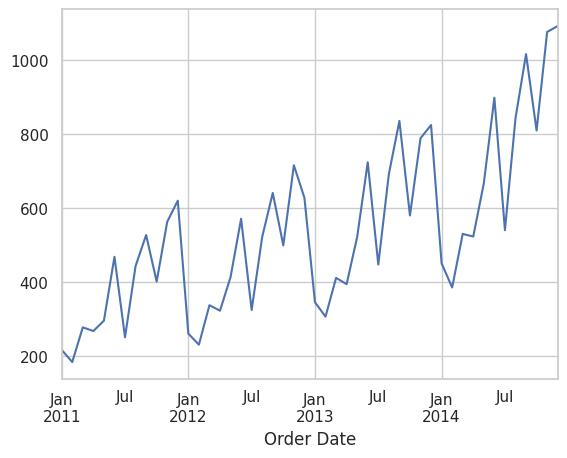

In [ ]:
# 13. Monthly Orders
monthly_orders = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Order ID'].nunique()

monthly_orders.plot()

# Insight

*   trend is upward
*   There are regular peaks and dips,2014 has the highest order volume.
*   Recomendations = Prepare inventory before peak months,Increase marketing during high-demand seasons,Investigate low-demand periods.



<Axes: xlabel='Sales', ylabel='Profit'>

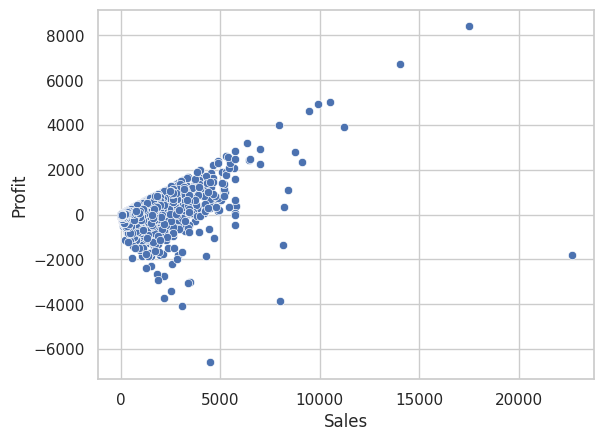

In [ ]:
# 14. Sales vs Profit
sns.scatterplot(
    x='Sales',
    y='Profit',
    data=df
)

# Insight


*   Most points move upward as sales increase,Some orders have high sales but negative profit,A few orders generate extremely high profits.
*   Recomendations = Investigate orders with high sales and negative profit,Review discount policies,Identify high-profit products and promote them.



<Axes: xlabel='Segment', ylabel='Profit'>

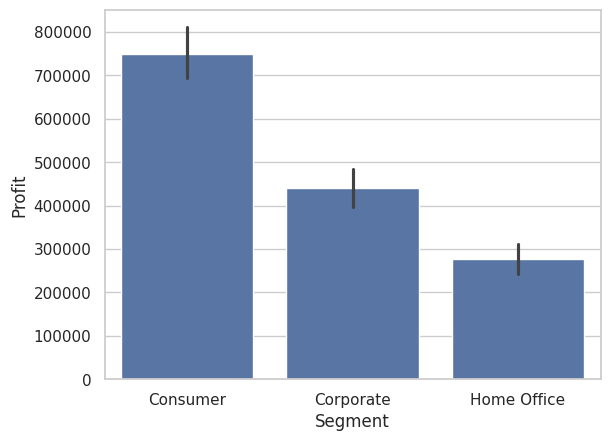

In [ ]:
# 15. Segment Analysis
sns.barplot(
    x='Segment',
    y='Profit',
    data=df,
    estimator=sum
)


# Insight
*   Consumer segment generates the highest profit,Corporate is second,Home Office contributes the least profit.
*   Recomendations = Invest more marketing budget in the Consumer segment,Study why Home Office customers spend less,Create special offers for Home Office customers.
